Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import scipy

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Step 2: Load & Copy the Dataset

In [2]:
df = pd.read_csv('music_dataset_mod.csv')
df_music_realistic = df.copy()
df_music_realistic.head()

,Tempo,Dynamics Range,Vocal Presence,Percussion Strength,String Instrument Detection,Electronic Element Presence,Rhythm Complexity,Drums Influence,Distorted Guitar,Metal Frequencies,Ambient Sound Influence,Instrumental Overlaps,Genre
0,114.618354,57.976367,53.251766,99.061840,14.686768,17.628630,46.545522,75.839434,79.378892,71.753088,96.439665,53.771763,Country
1,116.672803,69.387087,95.787280,90.831033,47.280419,-15.618194,85.421085,100.455908,0.713015,0.000000,17.327295,15.017146,Classical
2,128.328121,52.930677,65.701187,104.439247,5.984994,50.467388,18.006722,77.642913,80.652946,87.692110,95.125207,25.308020,Rock
3,128.511337,25.494755,14.095374,40.106130,47.715584,87.335201,68.603329,63.536557,74.888346,76.239108,97.016998,96.893109,Hip-hop
4,135.474190,45.174876,101.469872,70.002203,108.177637,25.865590,31.295163,81.121030,36.178193,23.381542,53.753793,30.142986,Country


Step 3: Explore the Data
Check structure & missing values:

In [3]:
df_music_realistic.info()
df_music_realistic.isnull().sum()   # See if there are missing values in any column
df_music_realistic.describe()       # Get summary statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Tempo                        1000 non-null   float64
 1   Dynamics Range               1000 non-null   float64
 2   Vocal Presence               1000 non-null   float64
 3   Percussion Strength          1000 non-null   float64
 4   String Instrument Detection  1000 non-null   float64
 5   Electronic Element Presence  1000 non-null   float64
 6   Rhythm Complexity            1000 non-null   float64
 7   Drums Influence              1000 non-null   float64
 8   Distorted Guitar             1000 non-null   float64
 9   Metal Frequencies            1000 non-null   float64
 10  Ambient Sound Influence      1000 non-null   float64
 11  Instrumental Overlaps        1000 non-null   float64
 12  Genre                        890 non-null    object 
dtypes: float64(12), obj

,Tempo,Dynamics Range,Vocal Presence,Percussion Strength,String Instrument Detection,Electronic Element Presence,Rhythm Complexity,Drums Influence,Distorted Guitar,Metal Frequencies,Ambient Sound Influence,Instrumental Overlaps
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,121.177891,46.684324,51.741685,54.854619,58.442054,48.813244,54.421479,76.646294,47.462577,47.319735,50.858454,49.328441
std,19.600614,17.809545,29.008872,29.489650,29.650752,33.239190,29.606431,18.867990,32.492813,32.274932,29.419584,29.140840
min,50.494818,-4.165724,0.408370,0.598517,0.217449,-29.990605,0.146433,18.995222,0.047202,0.000000,0.008879,0.254396
25%,107.885045,34.252531,26.635663,29.782438,32.240968,22.331010,29.603967,62.916792,11.678634,14.422842,24.832718,23.605648
50%,121.356455,46.390854,52.245242,54.926936,59.366659,49.871999,54.618441,75.739758,52.994852,50.722858,52.400507,50.106840
75%,135.054584,58.481545,76.919814,79.438614,82.872727,75.133776,78.502328,89.973436,75.149865,75.673932,77.304355,75.550700
max,175.982637,104.932942,109.643123,114.949678,119.991892,119.728293,119.699889,140.031079,99.586429,100.000000,99.820903,99.958673


Glance at the first few rows:

In [4]:
df_music_realistic.head()

,Tempo,Dynamics Range,Vocal Presence,Percussion Strength,String Instrument Detection,Electronic Element Presence,Rhythm Complexity,Drums Influence,Distorted Guitar,Metal Frequencies,Ambient Sound Influence,Instrumental Overlaps,Genre
0,114.618354,57.976367,53.251766,99.061840,14.686768,17.628630,46.545522,75.839434,79.378892,71.753088,96.439665,53.771763,Country
1,116.672803,69.387087,95.787280,90.831033,47.280419,-15.618194,85.421085,100.455908,0.713015,0.000000,17.327295,15.017146,Classical
2,128.328121,52.930677,65.701187,104.439247,5.984994,50.467388,18.006722,77.642913,80.652946,87.692110,95.125207,25.308020,Rock
3,128.511337,25.494755,14.095374,40.106130,47.715584,87.335201,68.603329,63.536557,74.888346,76.239108,97.016998,96.893109,Hip-hop
4,135.474190,45.174876,101.469872,70.002203,108.177637,25.865590,31.295163,81.121030,36.178193,23.381542,53.753793,30.142986,Country


Step 4: Understand Columns
Optionally: Refer to your legend file (check Colab Files tab, or add as a text cell).

Step 5: Analyze "Genre" Values
Find unique genres and their counts:

In [5]:
print(df_music_realistic['Genre'].unique())
print(df_music_realistic['Genre'].value_counts())

['Country' 'Classical' 'Rock' 'Hip-hop' nan 'Jazz']
Genre
Rock         190
Jazz         190
Country      180
Hip-hop      168
Classical    162
Name: count, dtype: int64


Plot genre distribution:

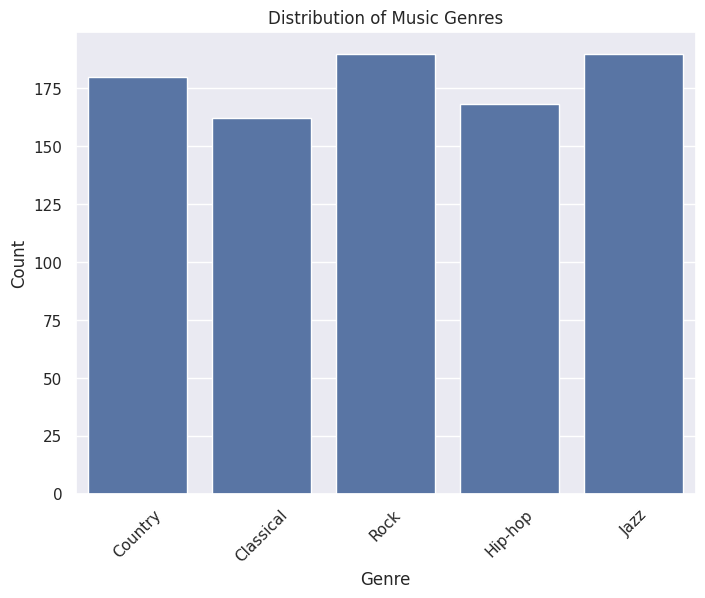

In [6]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Genre', data=df_music_realistic)
plt.title('Distribution of Music Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Step 6: Data Preprocessing
Encode target genre:

In [7]:
le = LabelEncoder()
df_music_realistic['Genre_encoded'] = le.fit_transform(df_music_realistic['Genre'])

Separate features & target:

In [8]:
X = df_music_realistic.drop(['Genre', 'Genre_encoded'], axis=1)
y = df_music_realistic['Genre_encoded']

Train-test split:

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Scale features:

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 7: Dimensionality Reduction with PCA
Apply PCA to reduce dimensions (let’s keep, say, 5 components):

In [11]:
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

Step 8: Build & Evaluate Model
Train logistic regression:

In [12]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_pca, y_train)

LogisticRegression(max_iter=1000)

Predict and evaluate:

In [14]:
y_pred = clf.predict(X_test_pca)

# Convert all labels in le.classes_ to strings to prevent TypeError
# caused by np.nan values when used as target_names.
string_target_names = [str(name) for name in le.classes_]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=string_target_names))

Accuracy: 0.455
              precision    recall  f1-score   support

   Classical       0.67      0.91      0.77        32
     Country       0.35      0.47      0.40        36
     Hip-hop       0.29      0.06      0.10        34
        Jazz       0.42      0.53      0.47        38
        Rock       0.43      0.61      0.51        38
         nan       0.00      0.00      0.00        22

    accuracy                           0.46       200
   macro avg       0.36      0.43      0.37       200
weighted avg       0.38      0.46      0.40       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Step 9: Visualize PCA
To explore clustering visually:

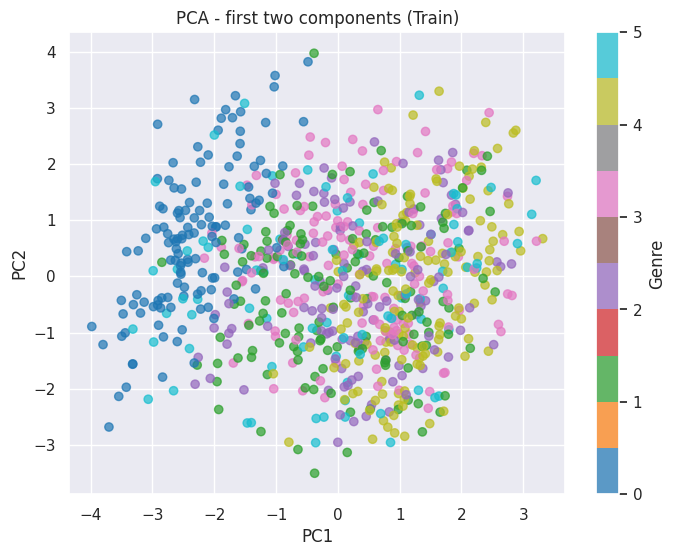

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='tab10', alpha=0.7)
plt.title('PCA - first two components (Train)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Genre')
plt.show()

## Step 10: Conclusion and Findings

### Data Exploration Summary

*   **Genre Distribution**: The dataset contains five main music genres: Rock, Jazz, Country, Hip-hop, and Classical. There were also some `nan` values in the 'Genre' column, which were handled during preprocessing.
*   **Missing Values**: The 'Genre' column had approximately 11% missing values (110 out of 1000 entries).

### Model Performance

*   **Accuracy**: The Logistic Regression model achieved an overall accuracy of **45.5%** on the test set after dimensionality reduction with PCA.
*   **Per-Genre Performance**:
    *   **Classical**: Showed the best performance with an f1-score of **0.77**.
    *   **Rock**: Performed moderately well with an f1-score of **0.51**.
    *   **Country**: Had an f1-score of **0.40**.
    *   **Hip-hop**: Showed poor performance with an f1-score of **0.10**.
    *   **nan**: Metrics for the 'nan' category were 0.00, indicating that the model did not correctly classify or predict these samples, likely due to their sparse presence or the way they were handled during encoding.

### Areas for Improvement

1.  **Handling Missing Values**: The presence of `nan` values in the 'Genre' column significantly impacted the model. Future improvements could involve more sophisticated imputation techniques for missing genres (if applicable) or simply dropping rows with missing genre labels if they are not critical for the analysis.
2.  **Feature Engineering**: Explore creating new features from existing ones or incorporating external data that could provide more discriminatory power for genre classification.
3.  **Model Selection**: Experiment with other classification algorithms beyond Logistic Regression, such as Support Vector Machines (SVMs), Random Forests, Gradient Boosting, or neural networks, which might capture more complex relationships in the data.
4.  **Hyperparameter Tuning**: Optimize the hyperparameters of the chosen model (e.g., regularization strength for Logistic Regression, number of estimators for tree-based models) to further enhance performance.
5.  **PCA Components**: Re-evaluate the number of PCA components. While 5 components were chosen, analyzing the explained variance ratio could guide a more optimal number of components.
6.  **Addressing Class Imbalance**: If certain genres are underrepresented, techniques like oversampling (e.g., SMOTE) or undersampling could help improve the model's ability to predict minority classes, especially for 'Hip-hop' which had very low recall and precision.

Overall, the initial analysis provides a baseline for music genre classification. Further work on data preprocessing, feature engineering, and model optimization is recommended to achieve better predictive accuracy.